# **Mumbai Housing Analysis and Prediction**

## **1) Data Loading and Data Preprocessing**

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    classification_report, mean_squared_error, mean_absolute_error, r2_score)
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

In [11]:
# Load dataset
df = pd.read_csv('Mumbai.csv')
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset loaded successfully!
Dataset shape: (7719, 40)


,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
0,4850000,720,Kharghar,1,1,1,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
1,4500000,600,Kharghar,1,1,1,1,1,0,1,...,1,0,1,0,0,0,0,0,0,0
2,6700000,650,Kharghar,1,1,1,1,1,0,1,...,1,0,1,0,0,0,0,0,0,0
3,4500000,650,Kharghar,1,1,1,0,0,1,0,...,1,1,1,0,0,0,0,0,1,0
4,5000000,665,Kharghar,1,1,1,0,0,1,0,...,1,0,1,0,0,0,0,0,0,0


### **Check missing values**

In [12]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Price                  0
Area                   0
Location               0
No. of Bedrooms        0
Resale                 0
MaintenanceStaff       0
Gymnasium              0
SwimmingPool           0
LandscapedGardens      0
JoggingTrack           0
RainWaterHarvesting    0
IndoorGames            0
ShoppingMall           0
Intercom               0
SportsFacility         0
ATM                    0
ClubHouse              0
School                 0
24X7Security           0
PowerBackup            0
CarParking             0
StaffQuarter           0
Cafeteria              0
MultipurposeRoom       0
Hospital               0
WashingMachine         0
Gasconnection          0
AC                     0
Wifi                   0
Children'splayarea     0
LiftAvailable          0
BED                    0
VaastuCompliant        0
Microwave              0
GolfCourse             0
TV                     0
DiningTable            0
Sofa                   0
Wardrobe               0
Refrige

### **Data Types Information**

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7719 entries, 0 to 7718
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Price                7719 non-null   int64 
 1   Area                 7719 non-null   int64 
 2   Location             7719 non-null   object
 3   No. of Bedrooms      7719 non-null   int64 
 4   Resale               7719 non-null   int64 
 5   MaintenanceStaff     7719 non-null   int64 
 6   Gymnasium            7719 non-null   int64 
 7   SwimmingPool         7719 non-null   int64 
 8   LandscapedGardens    7719 non-null   int64 
 9   JoggingTrack         7719 non-null   int64 
 10  RainWaterHarvesting  7719 non-null   int64 
 11  IndoorGames          7719 non-null   int64 
 12  ShoppingMall         7719 non-null   int64 
 13  Intercom             7719 non-null   int64 
 14  SportsFacility       7719 non-null   int64 
 15  ATM                  7719 non-null   int64 
 16  ClubHo

### **Encode categorical variables (Location)**

In [14]:
le = LabelEncoder()
df['Location'] = le.fit_transform(df['Location'])

### **Separate features and target**

In [15]:
X = df.drop('Price', axis=1)
y = df['Price']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (7719, 39)
Target shape: (7719,)


## **2) Detecting and Removing Outliers**

### **Detect outliers using IQR method for Price**

In [16]:
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = y[(y < lower_bound) | (y > upper_bound)]
print(f"Outliers detected in Price: {len(outliers)} ({len(outliers)/len(y)*100:.2f}%)")

# Remove outliers
clean_mask = (y >= lower_bound) & (y <= upper_bound)
X_clean = X[clean_mask]
y_clean = y[clean_mask]

print(f"Dataset after outlier removal: {X_clean.shape[0]} samples")

Outliers detected in Price: 589 (7.63%)
Dataset after outlier removal: 7130 samples


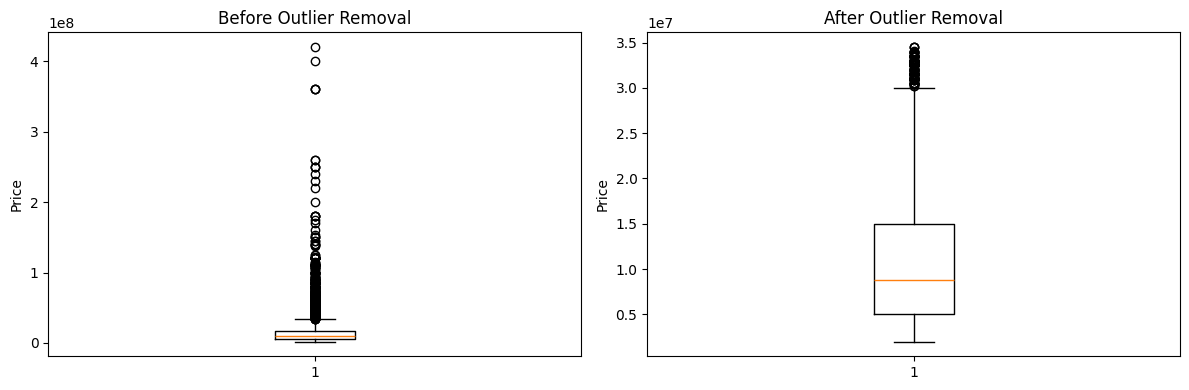

In [17]:
# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(y)
axes[0].set_title('Before Outlier Removal')
axes[0].set_ylabel('Price')
axes[1].boxplot(y_clean)
axes[1].set_title('After Outlier Removal')
axes[1].set_ylabel('Price')
plt.tight_layout()
plt.show()

## **3) Data Visualizations**

### **Distribution of Price**

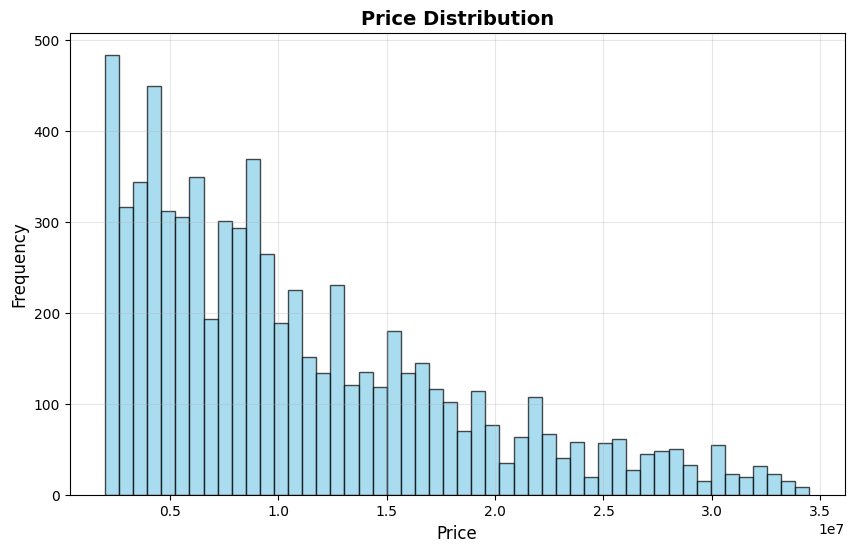

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(y_clean, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Price Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### **Price Distribution by Location**

<Figure size 1200x600 with 0 Axes>

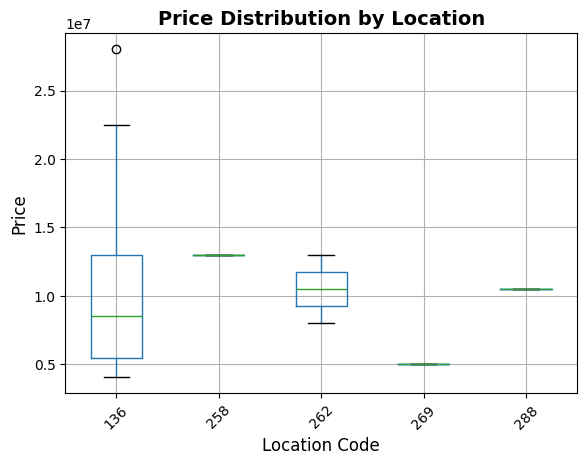

In [19]:
plt.figure(figsize=(12, 6))
df_temp = pd.DataFrame({'Location': X_clean['Location'], 'Price': y_clean}).head(200)
df_temp.boxplot(column='Price', by='Location', grid=True)
plt.title('Price Distribution by Location', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Location Code', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### **Area vs Price Scatter Plot**

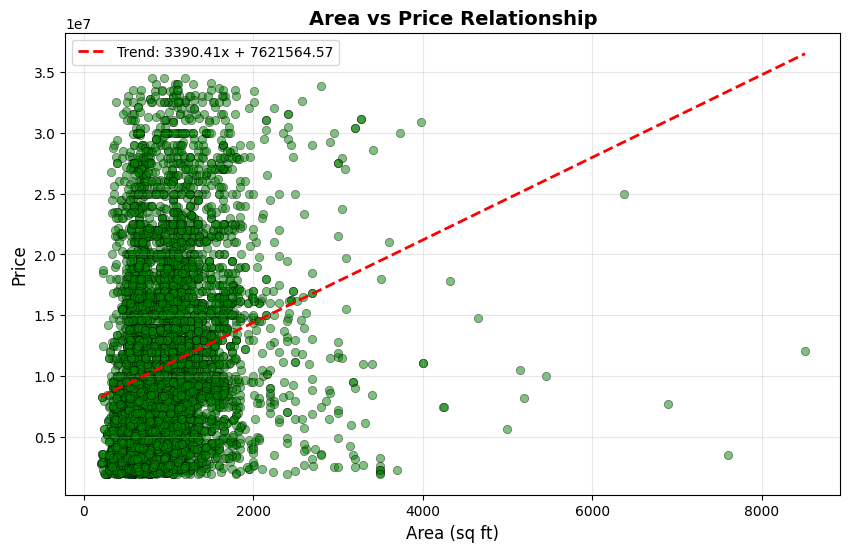

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(X_clean['Area'], y_clean, alpha=0.5, c='green', edgecolors='black', linewidth=0.5)
plt.title('Area vs Price Relationship', fontsize=14, fontweight='bold')
plt.xlabel('Area (sq ft)', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, alpha=0.3)

z = np.polyfit(X_clean['Area'], y_clean, 1)
p = np.poly1d(z)
x_sorted = np.sort(X_clean['Area'])
plt.plot(x_sorted, p(x_sorted), "r--", linewidth=2, label=f'Trend: {z[0]:.2f}x + {z[1]:.2f}')
plt.legend()
plt.show()

## **4) Splitting the Data**

In [21]:
# Split data (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Standardize features (only numeric columns)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 5704
Test set size: 1426


## **5) Applying Regression Models**

In [22]:
# Initialize models
regression_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train regression models
trained_reg_models = {}
for name, model in regression_models.items():
    model.fit(X_train_scaled, y_train)
    trained_reg_models[name] = model
    print(f"{name} trained successfully")

Linear Regression trained successfully
Ridge Regression trained successfully
Lasso Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
Gradient Boosting trained successfully


## **6) Evaluate Regression Models Performance**

In [23]:
# Evaluate all regression models
reg_results = []
for name, model in trained_reg_models.items():
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    
    reg_results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })

# Display regression results
reg_results_df = pd.DataFrame(reg_results)
reg_results_df = reg_results_df.sort_values('R2', ascending=False)
print("\n" + "="*80)
print("REGRESSION MODEL PERFORMANCE COMPARISON")
print("="*80)
print(reg_results_df.to_string(index=False))


REGRESSION MODEL PERFORMANCE COMPARISON
            Model         RMSE          MAE        R2   CV Mean   CV Std
Gradient Boosting 6.461046e+06 4.855120e+06  0.256147  0.261976 0.007389
    Random Forest 6.604875e+06 4.741000e+06  0.222661  0.182743 0.020960
Linear Regression 7.139077e+06 5.556446e+06  0.091834  0.091114 0.010214
 Ridge Regression 7.139207e+06 5.554578e+06  0.091801  0.095144 0.009783
 Lasso Regression 7.153835e+06 5.572789e+06  0.088075  0.094961 0.009479
    Decision Tree 7.919925e+06 5.351494e+06 -0.117695 -0.201114 0.058745


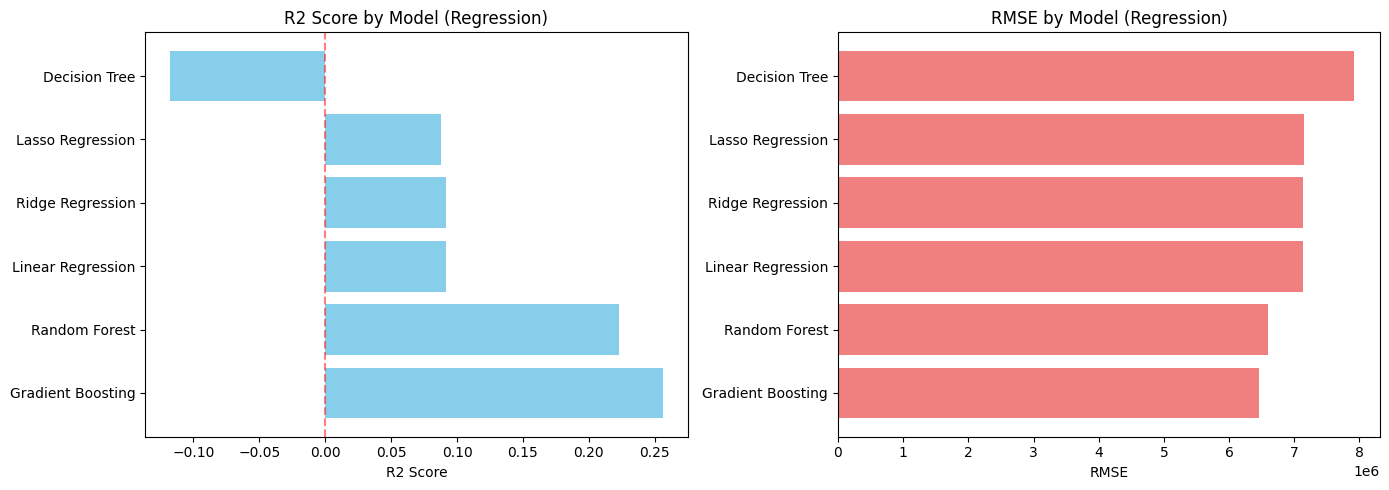

In [24]:
# Visualize regression comparisons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_names_reg = reg_results_df['Model']
r2_scores = reg_results_df['R2']
rmse_scores = reg_results_df['RMSE']

axes[0].barh(models_names_reg, r2_scores, color='skyblue')
axes[0].set_xlabel('R2 Score')
axes[0].set_title('R2 Score by Model (Regression)')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

axes[1].barh(models_names_reg, rmse_scores, color='lightcoral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE by Model (Regression)')

plt.tight_layout()
plt.show()

## **7) Selecting the Best Regression Model**

In [25]:
best_reg_model_name = reg_results_df.iloc[0]['Model']
best_reg_model = trained_reg_models[best_reg_model_name]
best_reg_r2 = reg_results_df.iloc[0]['R2']

print(f"\n{'='*50}")
print(f"BEST REGRESSION MODEL: {best_reg_model_name}")
print(f"R2 Score: {best_reg_r2:.4f}")
print(f"RMSE: {reg_results_df.iloc[0]['RMSE']:.2f}")
print(f"MAE: {reg_results_df.iloc[0]['MAE']:.2f}")
print(f"5-fold CV Mean: {reg_results_df.iloc[0]['CV Mean']:.4f} (+/- {reg_results_df.iloc[0]['CV Std']:.4f})")
print(f"{'='*50}")


BEST REGRESSION MODEL: Gradient Boosting
R2 Score: 0.2561
RMSE: 6461045.68
MAE: 4855120.01
5-fold CV Mean: 0.2620 (+/- 0.0074)


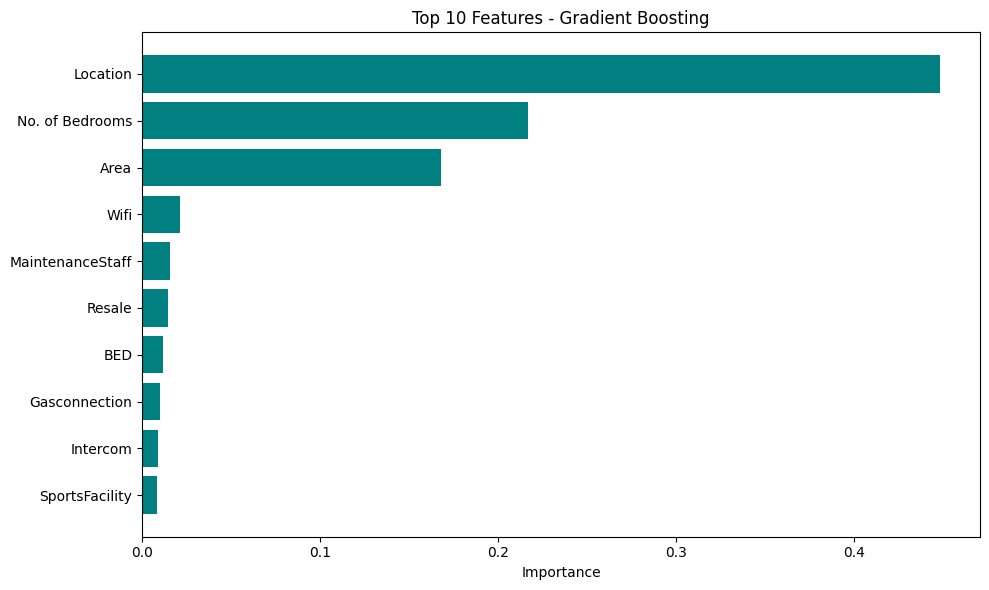

In [27]:
# Feature importance for tree-based models
if best_reg_model_name in ['Random Forest', 'Gradient Boosting', 'Decision Tree']:
    importance = pd.DataFrame({
        'feature': X_clean.columns,
        'importance': best_reg_model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['feature'], importance['importance'], color='teal')
    plt.xlabel('Importance')
    plt.title(f'Top 10 Features - {best_reg_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

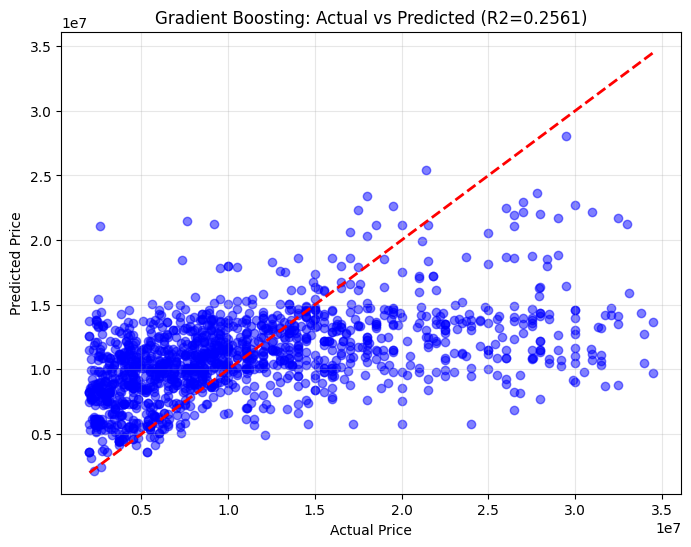

In [28]:
# Predictions vs Actual for best regression model
y_pred_best_reg = best_reg_model.predict(X_test_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best_reg, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'{best_reg_model_name}: Actual vs Predicted (R2={best_reg_r2:.4f})')
plt.grid(True, alpha=0.3)
plt.show()

## **8) Classification Model Implementation**

In [29]:
# Create categorical target variable from Price
price_quantiles = y_clean.quantile([0.33, 0.67])

def categorize_price(price):
    if price <= price_quantiles.iloc[0]:
        return 'Low'
    elif price <= price_quantiles.iloc[1]:
        return 'Medium'
    else:
        return 'High'

y_categorical = y_clean.apply(categorize_price)
X_classification = X_clean.copy()

print("\n" + "="*50)
print("CLASSIFICATION MODEL IMPLEMENTATION")
print("="*50)
print("Price Category Distribution:")
print(y_categorical.value_counts())
print(f"\nCategory percentages:")
print(y_categorical.value_counts(normalize=True) * 100)


CLASSIFICATION MODEL IMPLEMENTATION
Price Category Distribution:
Price
Medium    2426
Low       2355
High      2349
Name: count, dtype: int64

Category percentages:
Price
Medium    34.025245
Low       33.029453
High      32.945302
Name: proportion, dtype: float64


In [30]:
# Split data for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)

# Scale features for classification
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [31]:
# Initialize classification models
classification_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

In [32]:
# Train and evaluate classification models
clf_results = []
trained_clf_models = {}

print("\nTraining Classification Models:")
print("-"*50)

for name, model in classification_models.items():
    model.fit(X_train_clf_scaled, y_train_clf)
    trained_clf_models[name] = model
    y_pred_clf = model.predict(X_test_clf_scaled)
    
    accuracy = accuracy_score(y_test_clf, y_pred_clf)
    precision = precision_score(y_test_clf, y_pred_clf, average='weighted')
    recall = recall_score(y_test_clf, y_pred_clf, average='weighted')
    f1 = f1_score(y_test_clf, y_pred_clf, average='weighted')
    
    cv_scores = cross_val_score(model, X_train_clf_scaled, y_train_clf, cv=5)
    
    clf_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    
    print(f"{name:25} - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")


Training Classification Models:
--------------------------------------------------
Logistic Regression       - Accuracy: 0.4551, F1-Score: 0.4477
Decision Tree             - Accuracy: 0.5498, F1-Score: 0.5480
Random Forest             - Accuracy: 0.5638, F1-Score: 0.5632
Gradient Boosting         - Accuracy: 0.5533, F1-Score: 0.5514
SVM                       - Accuracy: 0.4467, F1-Score: 0.4436
KNN                       - Accuracy: 0.5224, F1-Score: 0.5188


In [33]:
# Display classification results
clf_results_df = pd.DataFrame(clf_results)
clf_results_df = clf_results_df.sort_values('F1-Score', ascending=False)

print("\n" + "="*80)
print("CLASSIFICATION MODEL PERFORMANCE COMPARISON")
print("="*80)
print(clf_results_df.to_string(index=False))


CLASSIFICATION MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  CV Mean   CV Std
      Random Forest  0.563815   0.562971 0.563815  0.563191 0.572757 0.006511
  Gradient Boosting  0.553296   0.557339 0.553296  0.551397 0.572757 0.007700
      Decision Tree  0.549790   0.549240 0.549790  0.548012 0.558906 0.015331
                KNN  0.522440   0.528119 0.522440  0.518750 0.530509 0.014010
Logistic Regression  0.455119   0.452285 0.455119  0.447723 0.460907 0.014090
                SVM  0.446704   0.452144 0.446704  0.443570 0.455297 0.008886


In [34]:
# Select best classification model
best_clf_model_name = clf_results_df.iloc[0]['Model']
best_clf_model = trained_clf_models[best_clf_model_name]
best_clf_f1 = clf_results_df.iloc[0]['F1-Score']

print(f"\n{'='*50}")
print(f"BEST CLASSIFICATION MODEL: {best_clf_model_name}")
print(f"F1-Score: {best_clf_f1:.4f}")
print(f"Accuracy: {clf_results_df.iloc[0]['Accuracy']:.4f}")
print(f"Precision: {clf_results_df.iloc[0]['Precision']:.4f}")
print(f"Recall: {clf_results_df.iloc[0]['Recall']:.4f}")
print(f"5-fold CV Mean: {clf_results_df.iloc[0]['CV Mean']:.4f} (+/- {clf_results_df.iloc[0]['CV Std']:.4f})")
print(f"{'='*50}")


BEST CLASSIFICATION MODEL: Random Forest
F1-Score: 0.5632
Accuracy: 0.5638
Precision: 0.5630
Recall: 0.5638
5-fold CV Mean: 0.5728 (+/- 0.0065)


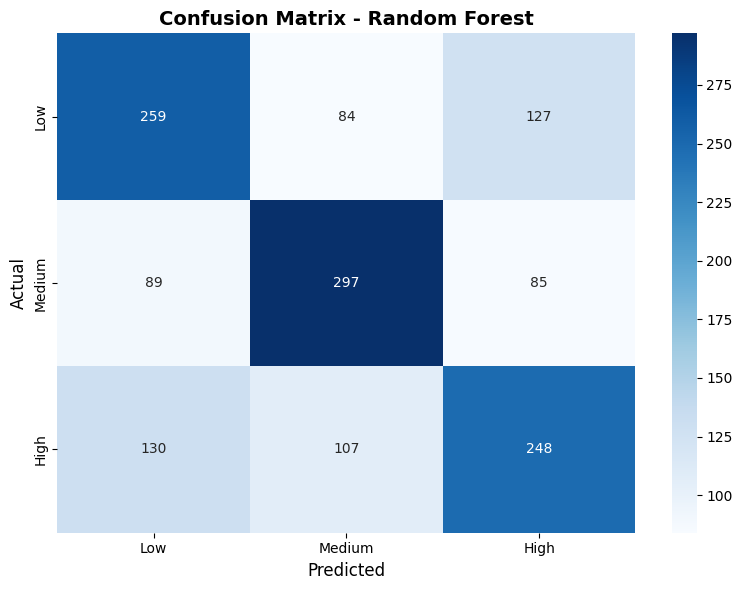

In [35]:
# Confusion Matrix for best classification model
y_pred_best_clf = best_clf_model.predict(X_test_clf_scaled)
cm = confusion_matrix(y_test_clf, y_pred_best_clf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title(f'Confusion Matrix - {best_clf_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

In [36]:
# Classification Report
print("\n" + "="*50)
print(f"CLASSIFICATION REPORT FOR BEST MODEL: {best_clf_model_name}")
print("="*50)
print(classification_report(y_test_clf, y_pred_best_clf, target_names=['Low', 'Medium', 'High']))


CLASSIFICATION REPORT FOR BEST MODEL: Random Forest
              precision    recall  f1-score   support

         Low       0.54      0.55      0.55       470
      Medium       0.61      0.63      0.62       471
        High       0.54      0.51      0.52       485

    accuracy                           0.56      1426
   macro avg       0.56      0.56      0.56      1426
weighted avg       0.56      0.56      0.56      1426



## **9) Cluster Analysis**

In [37]:
# Select features for clustering (using Area, No. of Bedrooms, and key amenities)
clustering_features = ['Area', 'No. of Bedrooms', 'Gymnasium', 'SwimmingPool', 
                        'ClubHouse', 'SportsFacility', 'CarParking', 'AC', 'Wifi']
X_cluster = X_clean[clustering_features].copy()

# Normalize the features for clustering
scaler_cluster = MinMaxScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"Features selected for clustering: {clustering_features}")
print(f"Clustering data shape: {X_cluster_scaled.shape}")

Features selected for clustering: ['Area', 'No. of Bedrooms', 'Gymnasium', 'SwimmingPool', 'ClubHouse', 'SportsFacility', 'CarParking', 'AC', 'Wifi']
Clustering data shape: (7130, 9)


### **Determine optimal number of clusters using Elbow Method**

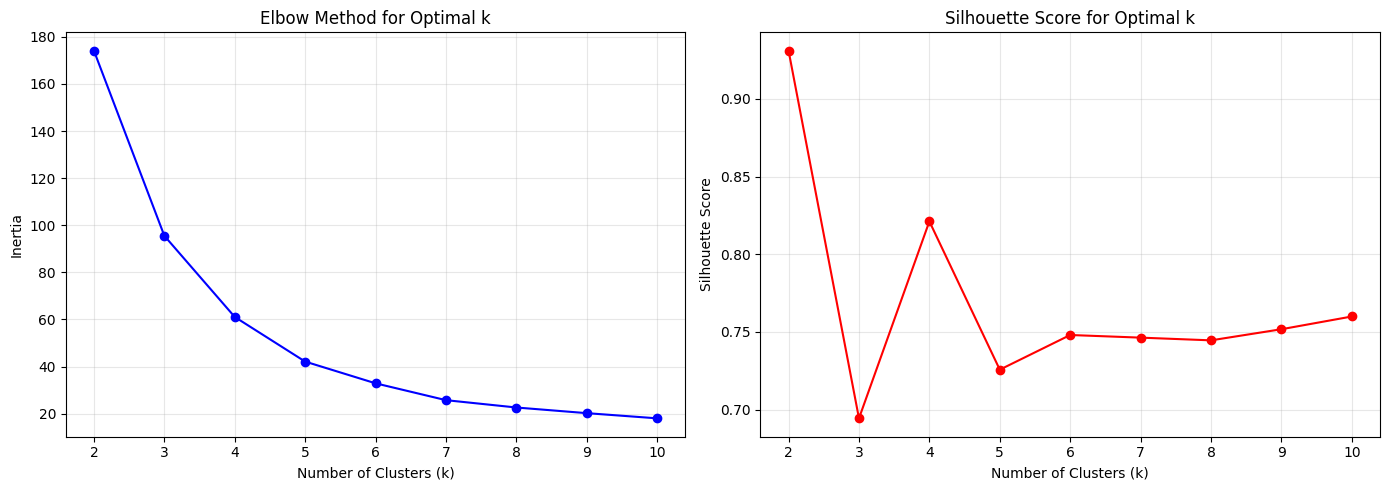

In [38]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    
    # Silhouette score
    from sklearn.metrics import silhouette_score
    silhouette_scores.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

# Plot Elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Optimal k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
# Determine optimal k (using elbow point and max silhouette score)
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2  # +2 because range starts at 2
print(f"\nOptimal number of clusters (based on Silhouette Score): {optimal_k}")


Optimal number of clusters (based on Silhouette Score): 2


### **Perform K-means clustering with optimal k**

In [40]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

# Add cluster labels to the original cleaned dataframe
X_clean_with_clusters = X_clean.copy()
X_clean_with_clusters['Cluster'] = cluster_labels
X_clean_with_clusters['Price'] = y_clean

print(f"\nCluster Distribution:")
print(X_clean_with_clusters['Cluster'].value_counts().sort_index())


Cluster Distribution:
Cluster
0    5820
1    1310
Name: count, dtype: int64


### **Visualize clustered data**

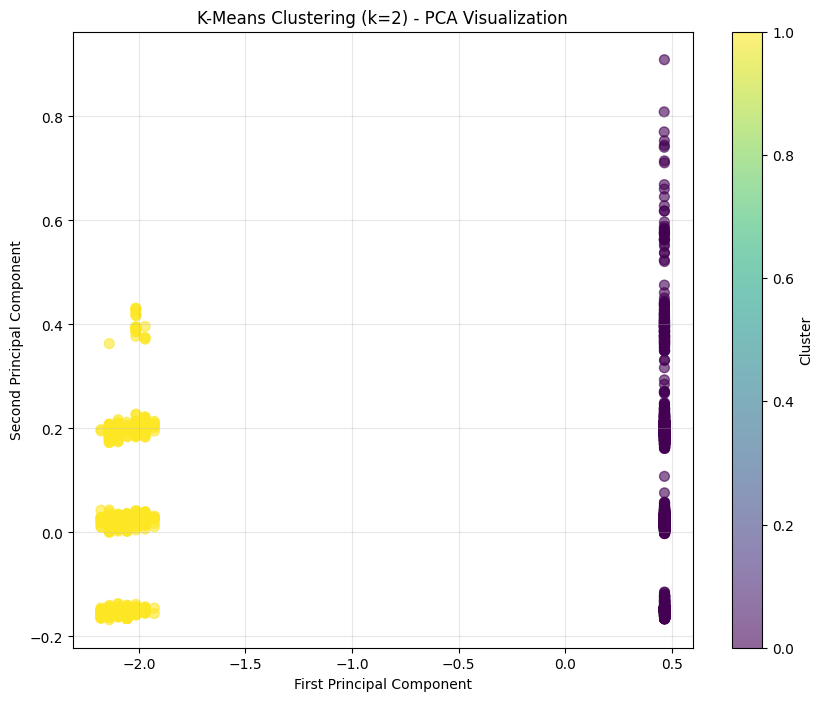

In [41]:
# 2D Visualization using first two principal components
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'K-Means Clustering (k={optimal_k}) - PCA Visualization')
plt.grid(True, alpha=0.3)
plt.show()

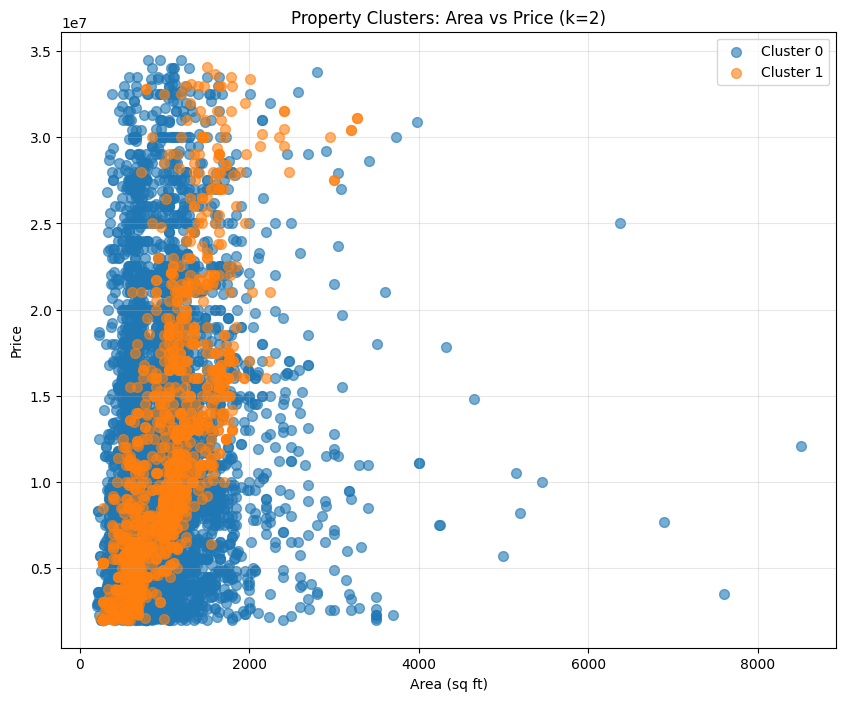

In [42]:
# Cluster visualization using Area and Price
plt.figure(figsize=(10, 8))
for cluster in range(optimal_k):
    cluster_data = X_clean_with_clusters[X_clean_with_clusters['Cluster'] == cluster]
    plt.scatter(cluster_data['Area'], cluster_data['Price'], 
                label=f'Cluster {cluster}', alpha=0.6, s=50)
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.title(f'Property Clusters: Area vs Price (k={optimal_k})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()